In [2]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [3]:
tickers = ["HDFCBANK.NS", "KOTAKBANK.NS"]

df = yf.download(tickers, start="2021-01-01", end="2026-01-01",auto_adjust=False,multi_level_index=False)['Adj Close']
df.columns = ['hdfcbank', 'kotakbank']
df.dropna(inplace=True)

import statsmodels.api as sm

X = df['kotakbank']
y = df['hdfcbank']

model = sm.OLS(y, X).fit()
beta = model.params[0]

df['spread'] = df['hdfcbank'] - beta * df['kotakbank']

from statsmodels.tsa.stattools import adfuller

adf = adfuller(df['spread'], maxlag=1)

t_stat = adf[0]
critical = adf[4]['10%']

print(t_stat < critical)

[*********************100%***********************]  2 of 2 completed

True


In [4]:
window = 90
results = []

for i in range(window, len(df)):
    spread_slice = df['spread'].iloc[i-window:i]
    adf = adfuller(spread_slice, maxlag=1)

    results.append(adf[0] < adf[4]['10%'])

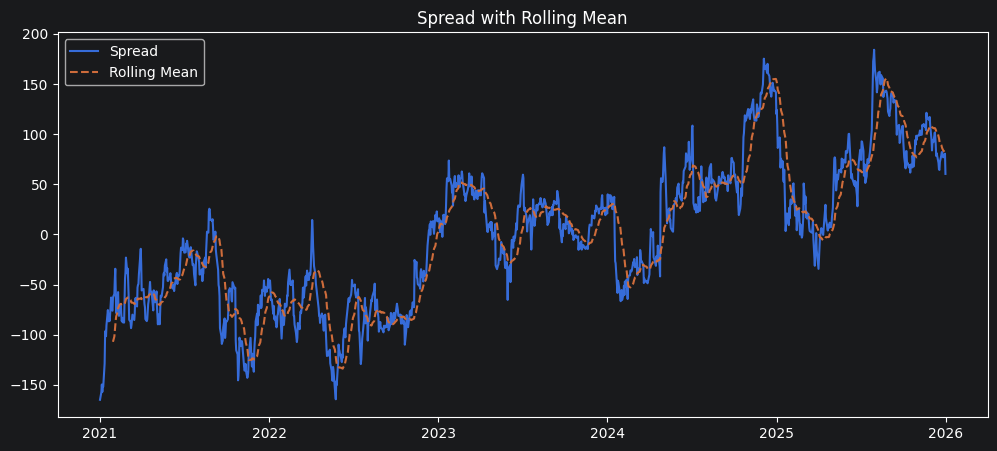

In [5]:
df['mean'] = df['spread'].rolling(20).mean()

plt.figure(figsize=(12,5))
plt.plot(df['spread'], label='Spread')
plt.plot(df['mean'], label='Rolling Mean', linestyle='--')
plt.legend()
plt.title("Spread with Rolling Mean")
plt.show()

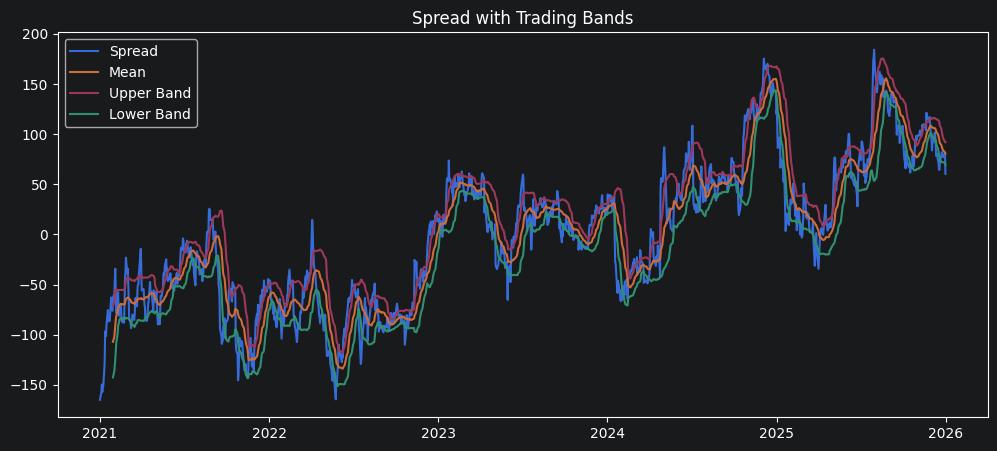

In [6]:
df['std'] = df['spread'].rolling(20).std()

df['upper'] = df['mean'] + df['std']
df['lower'] = df['mean'] - df['std']

plt.figure(figsize=(12,5))
plt.plot(df['spread'], label='Spread')
plt.plot(df['mean'], label='Mean')
plt.plot(df['upper'], label='Upper Band')
plt.plot(df['lower'], label='Lower Band')
plt.legend()
plt.title("Spread with Trading Bands")
plt.show()